#### Multilayer Neural Network Architecture (MLP - multilayer feedforward NN - fully connected network)

<img src="images/two_layer_mlp.png" width=450>

- The output is a kind of one-versus-all OvA strategy for multiclass. It is represented as the one-hot vector.
- The model's parameters are updated by the loss gradients via backpropagation.
- If the network is deep, then it may encounter vanishing gradient problem.

#### The MLP learning procedure:
(1) Starting at the input layer -> forward propagate through the network -> generate an output.\
(2) Compute loss using the loss/objective function.\
(3) Backpropagate the loss, find its derivative with respect to each weight and bias unit in the network, and update them.

##### Activation function 1: Sigmoid (Logistic) function
<img src='images/mlp_math_1.png' width=350>\
<img src='images/mlp_math_2.png' width=350>\
<img src='images/sigmoid.png' width=300>\
<img src='images/sigmoid_plot.png' width=350>

#### Classifying handwritten digits

In [51]:
# download the dataset
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [52]:
print(f"Type X, y: {type(X), type(y)}")
print(f"Shape X, y: {X.shape, y.shape}")

Type X, y: (<class 'pandas.core.frame.DataFrame'>, <class 'pandas.core.series.Series'>)
Shape X, y: ((70000, 784), (70000,))


In [53]:
print(X.info())
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB
None
        pixel1   pixel2   pixel3   pixel4   pixel5   pixel6   pixel7   pixel8  \
count  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel9  pixel10  ...      pixel775      pixel776      pixel777  \
count  70000.0  70000.0  ...  70

In [54]:
print(y.head())
print(y.info())
print(y.describe())

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']
<class 'pandas.core.series.Series'>
RangeIndex: 70000 entries, 0 to 69999
Series name: class
Non-Null Count  Dtype   
--------------  -----   
70000 non-null  category
dtypes: category(1)
memory usage: 68.9 KB
None
count     70000
unique       10
top           1
freq       7877
Name: class, dtype: object


In [55]:
y = y.astype(int).values
X = X.values
# normalization
X_normalized = ((X - 255.) - 0.5) * 2 # return the value -1 to 1

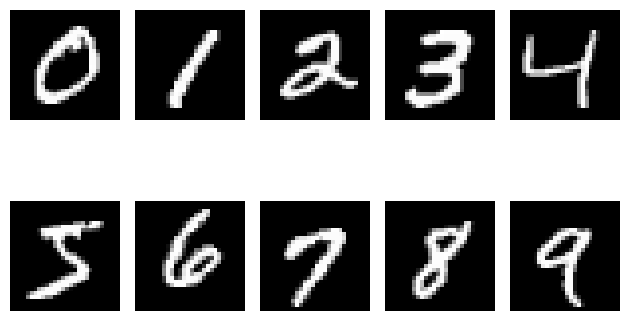

In [ ]:
# plot the images: 1 - 10
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)

ax = ax.flatten()

for i in range(10):
    # ax[i//5][i%5].imshow(X_normalized[y==i, :][0].reshape(28, 28), cmap="gray")
    ax[i].imshow(X_normalized[y==i][0].reshape(28, 28), cmap="gray")
    ax[i].axis('off')

# ax[0].set_xticks([])
# ax[0].set_yticks([])

plt.tight_layout()
plt.show()



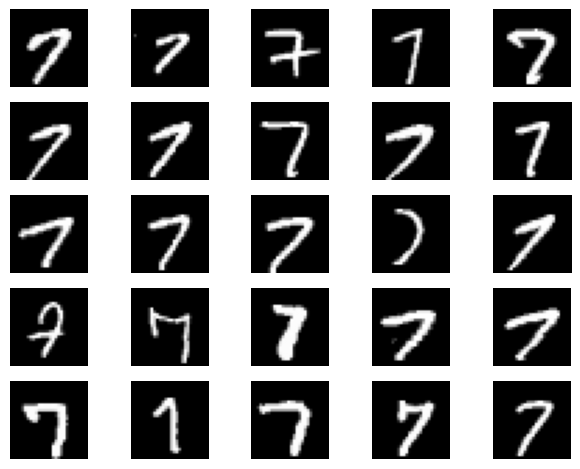

In [84]:
# plot the images: variants of 1 number 
selected_num = 7

fig, ax = plt.subplots(5, 5)
ax = ax.flatten()

for i in range(25):
    ax[i].imshow(X_normalized[y==selected_num][i].reshape(28, 28), cmap="gray")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [86]:
# split the dataset
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalized, y, test_size=10000, stratify=y, shuffle=True, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=5000, shuffle=True, random_state=2
)

In [89]:
import numpy as np
from utils.neural_network import NeuralNetMLP

model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_class=10)

#### The simple NN structure created

